In [1]:
# Implementation of a short straddle strategy selling ATM options expiry T = 3 months, no buy backs
# Daily PnL is calculated using capital gains of option premium 

'''
Sell ATM options on days when the portfolio doesn't already have open positions.
Rebalance the portfolio daily based on delta, either buying or short selling the underlying stock.
Calculate daily returns, taking into account the change in option premiums and the profit or loss from rebalancing the underlying stock.
Handle option expiration by checking if the options in the portfolio are expiring on the current day and calculating returns based on whether the options are exercised.
'''

import pandas as pd
import pandas_market_calendars as mcal
import numpy as np
import matplotlib.pyplot as plt
import math as math
from pandas import Timestamp
from equity import find_atm, reverse_option, get_hedge_count


/Users/emre/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/emre/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Load Data
AAPL_options_csv = 'apple_options.csv'
AAPL_underlying_csv = 'apple_stocks.csv'
AAPL_options = pd.read_csv(AAPL_options_csv, parse_dates = ["exdate", "date"])
AAPL_underlying = pd.read_csv(AAPL_underlying_csv, parse_dates = ["date"])
find_atm(AAPL_options_csv, AAPL_underlying_csv, pd.Timestamp(2022, 2, 28), 5, 90, 0.1)


[('AAPL 220520C155000', 'AAPL 220520P155000'),
 ('AAPL 220520C160000', 'AAPL 220520P160000'),
 ('AAPL 220520C165000', 'AAPL 220520P165000'),
 ('AAPL 220520C175000', 'AAPL 220520P175000'),
 ('AAPL 220520P150000', 'AAPL 220520C150000')]

In [17]:
def get_hedge_count(options_df: pd.DataFrame, options_symbols: list[str], date: pd.Timestamp) -> float:
    total_delta = 0
    for symbol in options_symbols:
        option_at_given_time = options_df.loc[(options_df["symbol"] == symbol) & (options_df["date"] == date)]

        if not option_at_given_time.empty:
            delta = option_at_given_time["delta"].iloc[0]
            if not pd.isna(delta):
                total_delta += delta
        else:
            # Handle the case where the option_at_given_time DataFrame is empty
            print(f"No data for {symbol} on {date}")
            continue  # Skip to the next iteration if no data found

    return total_delta

def backtest_short_straddle_with_premium_change(options_df, underlying_df, start_date, end_date):
    portfolio = {'options': [], 'underlying': 0, 'cash': 0}
    daily_returns = []
    previous_cash = 0 # Initialize previous day's cash balance
    nyse_calendar = mcal.get_calendar('NYSE')

    atm_options = find_atm(AAPL_options_csv, AAPL_underlying_csv, start_date, 2, 90, 0.1)
    print(atm_options)
    for call_id, put_id in atm_options:
        call_data = options_df.loc[options_df['symbol'] == call_id].iloc[0]
        put_data = options_df.loc[options_df['symbol'] == put_id].iloc[0]
        call_premium = ((call_data['best_bid'] + call_data['best_offer']) / 2) * call_data['contract_size']
        put_premium = ((put_data['best_bid'] + put_data['best_offer']) / 2) * put_data['contract_size']
        portfolio['options'].append({'data': call_data, 'symbol': call_id, 'premium_received': call_premium})
        portfolio['options'].append({'data': put_data, 'symbol': put_id, 'premium_received': put_premium})
        portfolio['cash'] += call_premium + put_premium

    options_df_start_date = options_df[options_df["date"] == start_date]
    expiry_date_list = []
    for option in portfolio["options"]:
        expiry_date_list.append(option["data"]["exdate"])
    expiry_date_set = set(expiry_date_list)
    max_expiry = max(expiry_date_set)

    trading_days = nyse_calendar.schedule(start_date, max_expiry)
    trading_day_index = mcal.date_range(trading_days, frequency='1D')
    # Change all dates to timestamps, with time 00:00:00
    trading_day_index = [pd.Timestamp(date.date()) for date in trading_day_index]

    for current_date in trading_day_index:
        spot_price = underlying_df.loc[underlying_df['date'] == current_date, 'PRC'].item()
        daily_unrealized_pnl = 0  # Initialize daily unrealized profit/loss from options
        # Process options expiring today
        options_to_remove = []
        for option in portfolio['options']:
            option_data_latest = options_df[options_df["date"] == current_date]
            option_data_latest= option_data_latest[option_data_latest["symbol"] == option["symbol"]]
            # Fetch the option data that is most current as of the current_date
            #option_data_latest = options_df.loc[(options_df['symbol'] == option['symbol']) & (options_df['date'] <= current_date)].sort_values(by='date').iloc[-1]
            exdate = option['data']['exdate']

            if exdate == current_date:
                # Calculate and realize P&L from option expiration
                option_type = option["symbol"].split()[1][6]
                pnl = min(spot_price - (option["data"]["strike_price"]/1000), 0) if 'P' == option_type else min(-spot_price + (option["data"]["strike_price"]/1000), 0)
                pnl *= option["data"]['contract_size']
                contract_size = option["data"]['contract_size']
                portfolio['cash'] += pnl
                options_to_remove.append(option)
            else:
                # Calculate unrealized P&L for non-expiring options using the most recent premium information
                current_premium = ((option_data_latest['best_bid'].values[0] + option_data_latest['best_offer'].values[0]) / 2) * option["data"]['contract_size']
                daily_unrealized_pnl -= current_premium 

        daily_unrealized_pnl += spot_price * portfolio["underlying"]
        # Remove expired options
        for option in options_to_remove:
            portfolio['options'].remove(option)

        # Daily rebalance based on delta
        portfolio_option_symbols = [option['symbol'] for option in portfolio['options']]
        daily_pnl = daily_unrealized_pnl + portfolio["cash"] # Update to include cash change
        daily_pnl += spot_price * portfolio["underlying"]

        contract_size = 100 # TODO: Fix this
        if current_date != trading_day_index:
            delta_without_stocks = get_hedge_count(options_df, portfolio_option_symbols, current_date)
            delta_with_stocks = delta_without_stocks + (portfolio["underlying"] * (1/contract_size))
            portfolio_underlying = 0
            if (abs(delta_with_stocks) > 0.2):
                hedge_count = -int(round(delta_with_stocks * contract_size))
                portfolio["cash"] -= hedge_count * spot_price
                portfolio["underlying"] += hedge_count

        # Add daily unrealized P&L from options to daily returns
        # Calculate and include real cash changes in daily P&L
    
        daily_returns.append(daily_pnl)
        print(portfolio["underlying"])
        print(portfolio["cash"])
        print(daily_unrealized_pnl)
        print("NEW")

    return pd.Series(daily_returns, index=trading_day_index)

# Execute the backtest
daily_returns = backtest_short_straddle_with_premium_change(AAPL_options, AAPL_underlying, AAPL_options['date'].min(), AAPL_options['date'].max())

[('AAPL 190418C160000', 'AAPL 190418P160000'), ('AAPL 190418C155000', 'AAPL 190418P155000')]
0
4567.5
-4567.5
NEW
74
-5954.5599999999995
-4942.5
NEW
44
-1506.7603
6713.7392599999985
NEW
44
-1506.7603
2343.9195600000003
NEW
44
-1506.7603
2683.0
NEW
15
2939.2297
2933.1400000000003
NEW
15
2939.2297
-1500.4999999999995
NEW
15
2939.2297
-1358.1501500000004
NEW
44
-1410.7703000000001
-1377.5
NEW
23
1803.6999099999998
3342.5804399999997
NEW
23
1803.6999099999998
226.1199999999999
NEW
1
5232.619909999999
267.2800000000002
NEW
1
5232.619909999999
-3148.17999
NEW
1
5232.619909999999
-3299.2
NEW
1
5232.619909999999
-3288.58
NEW
26
1415.11991
-3229.8
NEW
-13
7567.75952
864.2597399999995
NEW
-13
7567.75952
-5349.4
NEW
11
3855.4397599999993
-5358.33987
NEW
-72
17571.18976
-1464.75
NEW
-72
17571.18976
-15381.18
NEW
-72
17571.18976
-15289.94
NEW
-116
25106.18976
-16049.0
NEW
-116
25106.18976
-24276.37884
NEW
-116
25106.18976
-24333.34116
NEW
-116
25106.18976
-23485.54
NEW
-116
25106.18976
-23437.06
NE

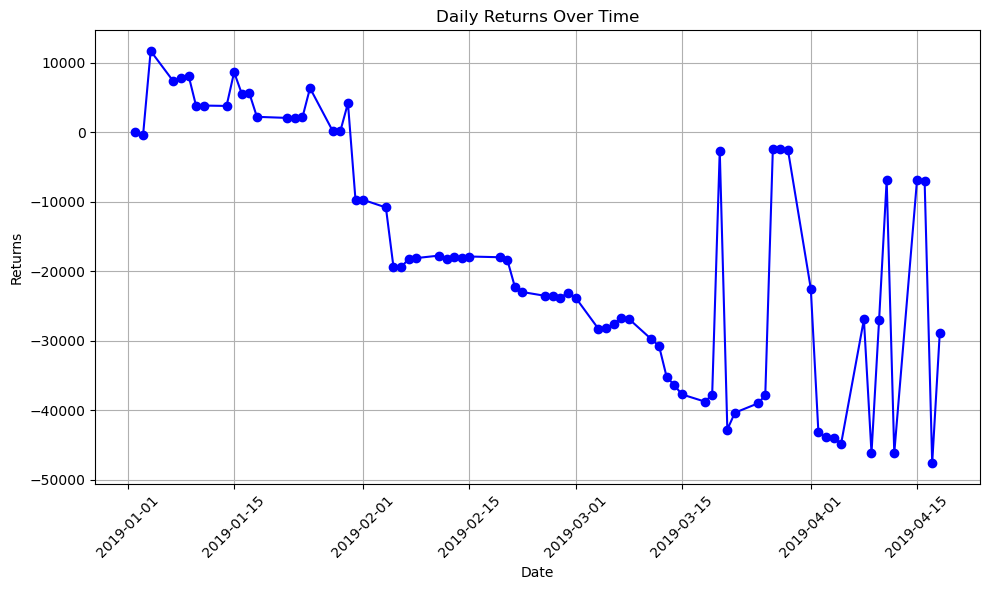

-28816.246350000016
2019-01-02        0.00000
2019-01-03     -375.00000
2019-01-04    11730.41852
2019-01-07     7346.07882
2019-01-08     7809.23970
                 ...     
2019-04-12   -46185.75635
2019-04-15    -6854.49635
2019-04-16    -6969.49635
2019-04-17   -47624.92635
2019-04-18   -28816.24635
Length: 75, dtype: float64


/var/folders/mr/4gcrkpn10sxggm2b1kxhnv5r0000gn/T/ipykernel_68480/4227643859.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(daily_returns[-1])


In [18]:
# Assuming daily_returns is a pandas Series with a datetime index
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(daily_returns.index, daily_returns.values, marker='o', linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

print(daily_returns[-1])
print(daily_returns)

In [ ]:
def get_hedge_count(options_df: pd.DataFrame, options_symbols: list[str], date: pd.Timestamp) -> int:
    total_delta = 0
    for symbol in options_symbols:
        option_at_given_time = options_df.loc[(options_df["symbol"] == symbol) & (options_df["date"] == date)]

        if not option_at_given_time.empty:
            delta = option_at_given_time["delta"].iloc[0]
            if not pd.isna(delta):
                total_delta += delta
        else:
            # Handle the case where the option_at_given_time DataFrame is empty
            print(f"No data for {symbol} on {date}")
            continue  # Skip to the next iteration if no data found

    return int(-1 * round(total_delta) * 100)

def backtest_short_straddle_with_premium_change(options_df, underlying_df, start_date, end_date):
    portfolio = {'options': [], 'underlying': 0, 'cash': 0}
    daily_returns = []
    previous_cash = 0 # Initialize previous day's cash balance
    nyse_calendar = mcal.get_calendar('NYSE')
    
    trading_days = nyse_calendar.schedule(start_date, end_date)
    trading_day_index = mcal.date_range(trading_days, frequency='1D')
    # Change all dates to timestamps, with time 00:00:00
    trading_day_index = [pd.Timestamp(date.date()) for date in trading_day_index]

    for current_date in trading_day_index:
        print(current_date)
        daily_unrealized_pnl = 0  # Initialize daily unrealized profit/loss from options
        
        # Process options expiring today
        options_to_remove = []
        for option in portfolio['options']:
            # Fetch the option data that is most current as of the current_date
            option_data_latest = options_df.loc[(options_df['symbol'] == option['symbol']) & (options_df['date'] <= current_date)].sort_values(by='date').iloc[-1]
            
            if option_data_latest['exdate'] == current_date:
                # Calculate and realize P&L from option expiration
                spot_price = underlying_df.loc[underlying_df['date'] == current_date, 'PRC'].item()
                pnl = max(option_data_latest['strike_price'] / 1000 - spot_price, 0) if 'P' in option_data_latest['symbol'] else max(spot_price - option_data_latest['strike_price'] / 1000, 0)
                pnl *= option_data_latest['contract_size']
                portfolio['cash'] += pnl - option['premium_received']
                options_to_remove.append(option)
            else:
                # Calculate unrealized P&L for non-expiring options using the most recent premium information
                current_premium = (option_data_latest['best_bid'] + option_data_latest['best_offer']) / 2
                premium_change = option['premium_received'] - current_premium * option_data_latest['contract_size']
                daily_unrealized_pnl += premium_change

        # Remove expired options
        for option in options_to_remove:
            portfolio['options'].remove(option)

        # Sell new ATM options if needed
        if not portfolio['options']:
            atm_options = find_atm(AAPL_options_csv, AAPL_underlying_csv, current_date, 10, 90, 0.5)
            for call_id, put_id in atm_options:
                call_data = options_df.loc[options_df['symbol'] == call_id].iloc[0]
                put_data = options_df.loc[options_df['symbol'] == put_id].iloc[0]
                call_premium = (call_data['best_bid'] + call_data['best_offer']) / 2 * call_data['contract_size']
                put_premium = (put_data['best_bid'] + put_data['best_offer']) / 2 * put_data['contract_size']
                portfolio['options'].append({'symbol': call_id, 'premium_received': call_premium})
                portfolio['options'].append({'symbol': put_id, 'premium_received': put_premium})
                portfolio['cash'] += call_premium + put_premium

        # Daily rebalance based on delta
        portfolio_option_symbols = [option['symbol'] for option in portfolio['options']]
            
        # hedge_count = get_hedge_count(options_df, portfolio_option_symbols, current_date)
        # underlying_df.head()
        # rebalance_cost = (hedge_count - portfolio['underlying']) * underlying_df.loc[underlying_df['date'] == current_date, 'PRC'].item()
        # portfolio['underlying'] = hedge_count
        # portfolio['cash'] -= rebalance_cost

        # # Adjusted rebalancing code snippet
        # hedge_adjustment = get_hedge_count(options_df, portfolio_option_symbols, current_date)
        # current_price = underlying_df.loc[underlying_df['date'] == current_date, 'PRC'].item()
        # rebalance_cost = hedge_adjustment * current_price
        # portfolio['underlying'] += hedge_adjustment  # Adjust the current holding based on the hedge count
        # portfolio['cash'] -= rebalance_cost  # Adjust the cash position based on the cost to rebalance

        # Add daily unrealized P&L from options to daily returns
        # Calculate and include real cash changes in daily P&L
        cash_change = portfolio['cash'] - previous_cash
        daily_pnl = daily_unrealized_pnl + cash_change  # Update to include cash change
        daily_returns.append(daily_pnl)

        previous_cash = portfolio['cash']

    return pd.Series(daily_returns, index=trading_day_index)

# Execute the backtest
daily_returns_no_rebalancing = backtest_short_straddle_with_premium_change(AAPL_options, AAPL_underlying, AAPL_options['date'].min(), AAPL_options['date'].max())

In [ ]:
print(daily_returns)
print(daily_returns_no_rebalancing)
print(daily_returns_no_rebalancing.sum())